# MODELISATION HYBRIDE ER : CHAIN LADDER + MACHINE LEARNING

## Approche innovante combinant methodes actuarielles et ML

### Principe :
1. **Chain Ladder (Actuariel)** : Matrices triangulaires de developpement par cohorte
2. **Machine Learning** : Ajustements individuels (2 etapes : Probabilite + Intensite)
3. **Modele hybride** : ER_final = ER_baseline × P(FLAG_ER=1) × E[ER|FLAG_ER=1]

### Structure :
- **PARTIE 1** : Construction des triangles de developpement
- **PARTIE 2** : Chain Ladder - Facteurs de developpement
- **PARTIE 3** : Projection baseline par cohorte
- **PARTIE 4** : Modele ML 2 etapes
- **PARTIE 5** : Modele hybride final
- **PARTIE 6** : Validation et projection


## IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from scipy.interpolate import interp1d
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotheques importees")

Bibliotheques importees


## PARTIE 1 : CHARGEMENT ET PREPARATION DES DONNEES

In [2]:
# Chargement
df = pd.read_excel("Base_ER_FR.xlsx")
print(f"Dataset charge : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Nettoyage de base
cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Conversion date
df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str) + "01", format="%Y%m%d", errors="coerce")

if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")

df = df[df.get("EAD", 1) > 0]
df["RA"] = df["RA"].fillna(0)

# Variables categorielles
cat_cols = ["CLASSACT", "CSP", "produit"]
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype("category")

# Imputation
df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(lambda x: x.fillna(x.median()))
df["Tx"] = df["Tx"].fillna(df["Tx"].median())
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

# Features engineering
df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]
df = df[df["AGE_PRET"] >= 0]
df = df[df["AGE_PRET"] <= df["B_MAT"]]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

print("Preparation terminee")

Dataset charge : 100000 lignes, 20 colonnes
Preparation terminee


In [3]:
# Calcul de l'encours et ER
df["Capital_emprunt"] = df["MTECH"] * ((1 - (1 + (df["Tx"] / 1200)) ** (-df["NB_ECH"])) / (df["Tx"] / 1200))
df["Montant_rembourse"] = ((df["B_MAT"] - df["B_RESMAT"]) * df["MTECH"].clip(lower=0)).round(2)
df["Encours"] = df["Capital_emprunt"] - df["Montant_rembourse"]
df["Encours"] = df["Encours"].clip(lower=1)

# ER = RA / Encours
df["ER_obs"] = df["RA"] / df["Encours"]
df["ER_obs"] = df["ER_obs"].clip(lower=0, upper=1)
df["FLAG_ER"] = (df["RA"] > 0).astype(int)

# Filtrer outliers
df = df[df["ER_obs"] <= 1]
df = df[df["Encours"] > 0]

# Creer cohorte (date d'origination)
df["Date_origination"] = df["DARRET"] - pd.to_timedelta(df["AGE_PRET"] * 30, unit='D')
df["Cohorte"] = df["Date_origination"].dt.to_period('M')

print(f"Donnees preparees : {len(df)} contrats")
print(f"Nombre de cohortes : {df['Cohorte'].nunique()}")
print(f"Periode couverte : {df['Cohorte'].min()} a {df['Cohorte'].max()}")

Donnees preparees : 26519 contrats
Nombre de cohortes : 302
Periode couverte : 1994-06 a 2023-12


## PARTIE 2 : CONSTRUCTION DES TRIANGLES DE DEVELOPPEMENT

Les triangles Run-off permettent de visualiser l'evolution de l'ER par cohorte et age du pret.

Structure :
- **Lignes** = Cohortes (date d'origination)
- **Colonnes** = Age du pret (mois depuis origination)
- **Valeurs** = ER moyen observé

In [4]:
# Triangle 1 : ER cumule par cohorte et age du pret
triangle_er_cumule = df.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='mean'
)

print("Triangle ER cumule (extrait 5x5) :")
print(triangle_er_cumule.iloc[:5, :5])

# Triangle 2 : Nombre de contrats par cohorte et age
triangle_volume = df.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='count'
)

print("\nTriangle volumes (extrait 5x5) :")
print(triangle_volume.iloc[:5, :5])

# Triangle 3 : Taux de remboursement anticipe (FLAG_ER)
triangle_taux_ra = df.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='FLAG_ER',
    aggfunc='mean'
)

print("\nTriangle taux RA (extrait 5x5) :")
print(triangle_taux_ra.iloc[:5, :5])

Triangle ER cumule (extrait 5x5) :
AGE_PRET  0.0  1.0  2.0  3.0  4.0
Cohorte                          
1994-06   NaN  NaN  NaN  NaN  NaN
1994-07   NaN  NaN  NaN  NaN  NaN
1994-08   NaN  NaN  NaN  NaN  NaN
1994-09   NaN  NaN  NaN  NaN  NaN
1994-10   NaN  NaN  NaN  NaN  NaN

Triangle volumes (extrait 5x5) :
AGE_PRET  0.0  1.0  2.0  3.0  4.0
Cohorte                          
1994-06   NaN  NaN  NaN  NaN  NaN
1994-07   NaN  NaN  NaN  NaN  NaN
1994-08   NaN  NaN  NaN  NaN  NaN
1994-09   NaN  NaN  NaN  NaN  NaN
1994-10   NaN  NaN  NaN  NaN  NaN

Triangle taux RA (extrait 5x5) :
AGE_PRET  0.0  1.0  2.0  3.0  4.0
Cohorte                          
1994-06   NaN  NaN  NaN  NaN  NaN
1994-07   NaN  NaN  NaN  NaN  NaN
1994-08   NaN  NaN  NaN  NaN  NaN
1994-09   NaN  NaN  NaN  NaN  NaN
1994-10   NaN  NaN  NaN  NaN  NaN


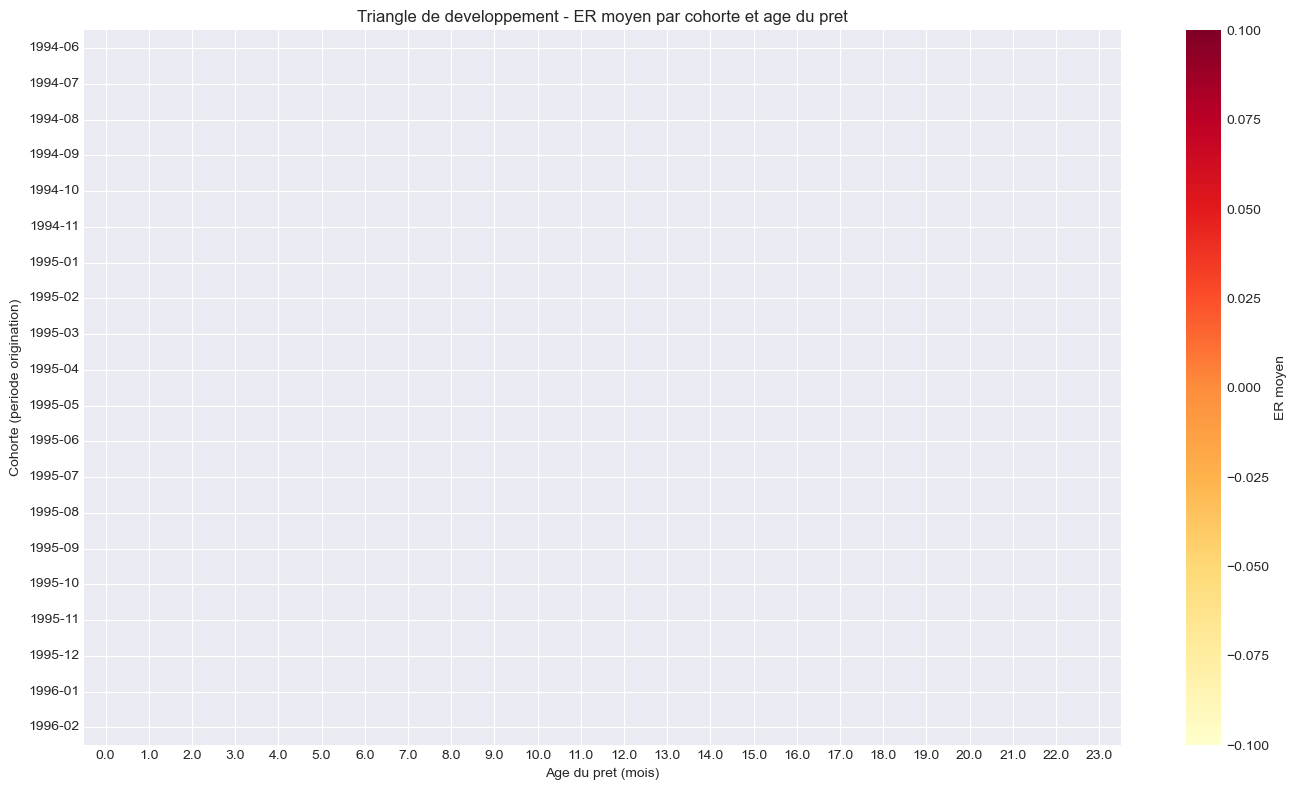

In [5]:
# Visualisation du triangle principal
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(triangle_er_cumule.iloc[:20, :24], annot=False, fmt='.3f', 
            cmap='YlOrRd', cbar_kws={'label': 'ER moyen'}, ax=ax)
ax.set_xlabel('Age du pret (mois)')
ax.set_ylabel('Cohorte (periode origination)')
ax.set_title('Triangle de developpement - ER moyen par cohorte et age du pret')
plt.tight_layout()
plt.show()

## PARTIE 3 : CHAIN LADDER - FACTEURS DE DEVELOPPEMENT

Methode actuarielle classique pour projeter les triangles incomplets.

Principe :
1. Calculer les facteurs de developpement : f_j = moyenne(ER(j+1) / ER(j))
2. Projeter les valeurs futures : ER(i,j+1) = ER(i,j) × f_j
3. Obtenir la courbe baseline moyenne

In [6]:
def calculate_development_factors(triangle):
    factors = {}
    for j in range(len(triangle.columns) - 1):
        col_current = triangle.columns[j]
        col_next = triangle.columns[j + 1]
        mask = (triangle[col_current] > 0) & (triangle[col_next].notna())
        if mask.sum() > 0:
            ratios = triangle.loc[mask, col_next] / triangle.loc[mask, col_current]
            weights = triangle.loc[mask, col_current]
            factor = np.average(ratios, weights=weights)
            factors[col_current] = factor
        else:
            factors[col_current] = 1.0
    return factors

factors_er = calculate_development_factors(triangle_er_cumule)

print("Facteurs de developpement (Chain Ladder) - Extrait :")
print("Age -> Facteur")
print("-" * 30)
for age, factor in sorted(factors_er.items())[:20]:
    print(f"{age:3.0f} -> {factor:.4f}")

Facteurs de developpement (Chain Ladder) - Extrait :
Age -> Facteur
------------------------------
  0 -> 1.4167
  1 -> 1.1978
  2 -> 0.7892
  3 -> 0.9965
  4 -> 0.9842
  5 -> 1.0277
  6 -> 1.0732
  7 -> 1.0003
  8 -> 1.0144
  9 -> 1.0718
 10 -> 0.9809
 11 -> 0.9014
 12 -> 0.9607
 13 -> 0.9915
 14 -> 1.0600
 15 -> 1.1366
 16 -> 0.9897
 17 -> 1.0301
 18 -> 0.8747
 19 -> 1.0171


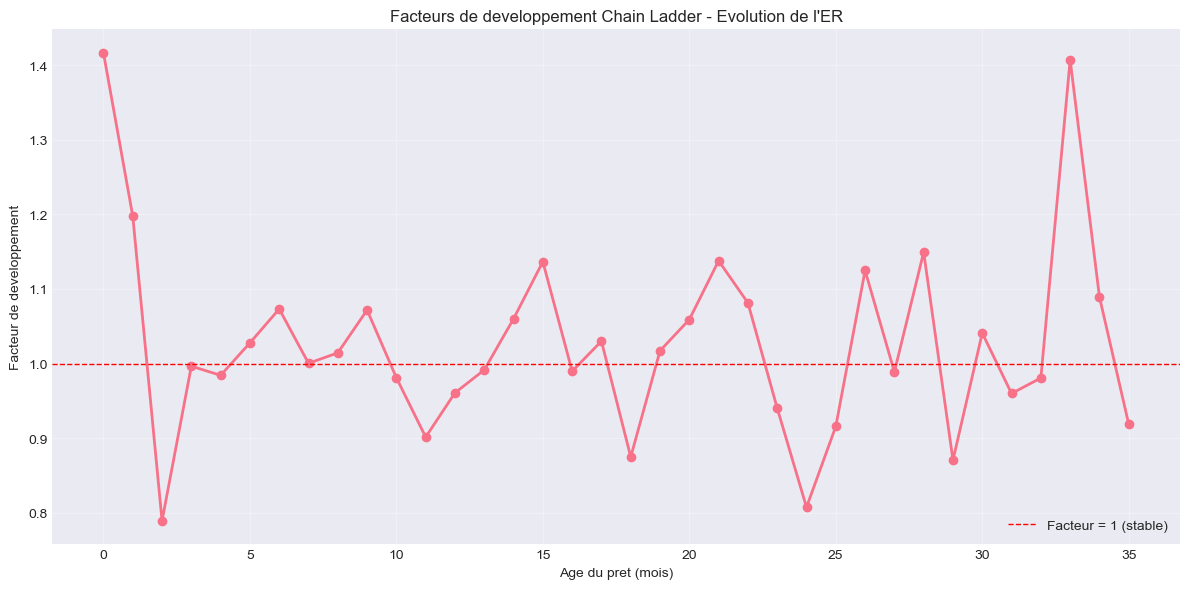

In [7]:
# Visualisation des facteurs
ages_factors = sorted(factors_er.keys())[:36]
values_factors = [factors_er[age] for age in ages_factors]

plt.figure(figsize=(12, 6))
plt.plot(ages_factors, values_factors, 'o-', linewidth=2, markersize=6)
plt.axhline(y=1.0, color='r', linestyle='--', linewidth=1, label='Facteur = 1 (stable)')
plt.xlabel('Age du pret (mois)')
plt.ylabel('Facteur de developpement')
plt.title('Facteurs de developpement Chain Ladder - Evolution de l\'ER')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
def project_triangle(triangle, factors, max_age=120):
    triangle_projected = triangle.copy()
    for cohorte in triangle_projected.index:
        last_observed = triangle_projected.loc[cohorte].last_valid_index()
        if last_observed is not None and last_observed < max_age:
            current_value = triangle_projected.loc[cohorte, last_observed]
            for age in range(int(last_observed) + 1, min(max_age + 1, len(triangle_projected.columns))):
                if age - 1 in factors:
                    factor = factors[age - 1]
                    projected_value = current_value * factor
                    if age in triangle_projected.columns:
                        triangle_projected.loc[cohorte, age] = projected_value
                    current_value = projected_value
    return triangle_projected

# Projeter le triangle ER
triangle_er_projected = project_triangle(triangle_er_cumule, factors_er, max_age=120)

# Calculer la courbe ER baseline moyenne (toutes cohortes)
er_baseline_by_age = triangle_er_projected.mean(axis=0)

print("ER baseline par age du pret (extrait) :")
print(er_baseline_by_age.head(20))

ER baseline par age du pret (extrait) :
AGE_PRET
0.0     0.383943
1.0     0.555822
2.0     0.663621
3.0     0.523453
4.0     0.515896
5.0     0.511196
6.0     0.525101
7.0     0.562716
8.0     0.559243
9.0     0.571157
10.0    0.612010
11.0    0.598764
12.0    0.538716
13.0    0.515586
14.0    0.519701
15.0    0.550296
16.0    0.627214
17.0    0.625306
18.0    0.645710
19.0    0.559855
dtype: float64


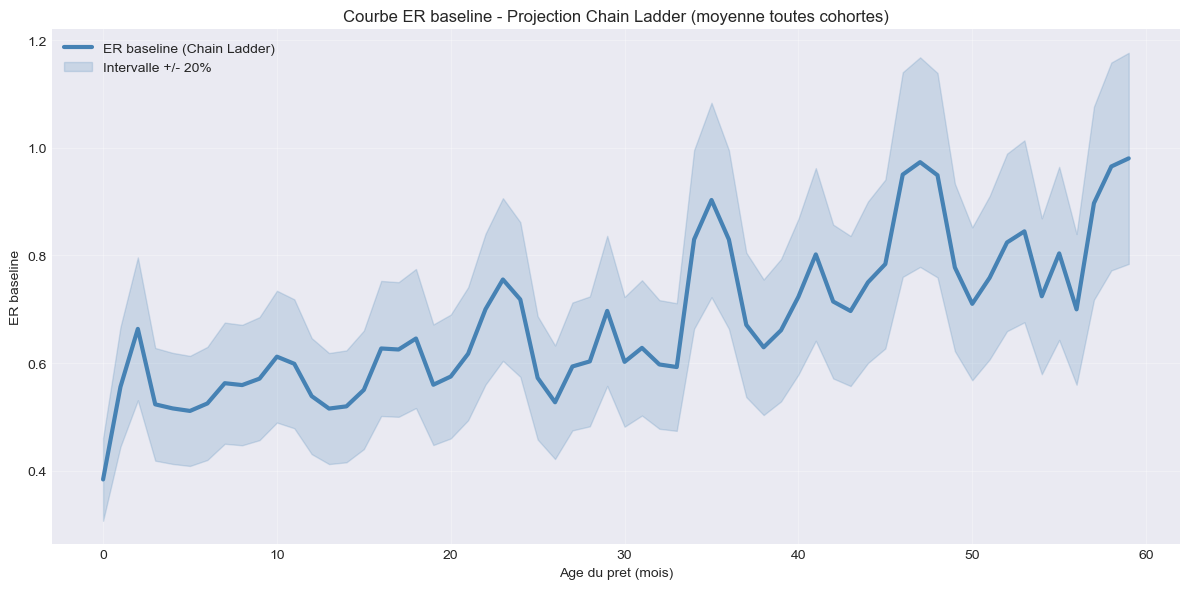

In [9]:
# Visualisation courbe baseline
plt.figure(figsize=(12, 6))
plt.plot(er_baseline_by_age.index[:60], er_baseline_by_age.values[:60], 
         linewidth=3, color='steelblue', label='ER baseline (Chain Ladder)')
plt.fill_between(er_baseline_by_age.index[:60], 
                 er_baseline_by_age.values[:60] * 0.8,
                 er_baseline_by_age.values[:60] * 1.2,
                 alpha=0.2, color='steelblue', label='Intervalle +/- 20%')
plt.xlabel('Age du pret (mois)')
plt.ylabel('ER baseline')
plt.title('Courbe ER baseline - Projection Chain Ladder (moyenne toutes cohortes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Ajouter la baseline au dataframe principal
df['ER_baseline'] = df['AGE_PRET'].map(er_baseline_by_age)
df['ER_baseline'] = df['ER_baseline'].fillna(method='ffill').fillna(method='bfill')

# Calculer l'ecart vs baseline
df['ER_ecart_baseline'] = df['ER_obs'] - df['ER_baseline']
df['ER_ratio_baseline'] = df['ER_obs'] / df['ER_baseline'].clip(lower=0.001)

print(f"ER moyen observe : {df['ER_obs'].mean():.4f}")
print(f"ER moyen baseline : {df['ER_baseline'].mean():.4f}")
print(f"Ratio moyen ER_obs/ER_baseline : {df['ER_ratio_baseline'].mean():.4f}")

ER moyen observe : 0.7819
ER moyen baseline : 1.1476
Ratio moyen ER_obs/ER_baseline : 0.9922


## PARTIE 4 : MODELE ML - AJUSTEMENTS INDIVIDUELS (2 ETAPES)

### Etape 1 : Modele de probabilite
P(FLAG_ER = 1 | X) - Predire si un remboursement anticipe aura lieu

### Etape 2 : Modele d'intensite
E[ER | FLAG_ER = 1, X] - Predire le montant du remboursement anticipe

Les features incluent la baseline comme variable explicative.

In [11]:
# Encodage variables categorielles
for col in ['CLASSACT', 'CSP', 'produit']:
    if col in df.columns:
        le = LabelEncoder()
        df[f"{col}_encoded"] = le.fit_transform(df[col].astype(str))

# Features pour ML (incluant la baseline comme feature)
ml_features = [
    'AGE_PRET', 'HORIZON_RES', 'Tx', 'MREVTOT', 'Capital_emprunt',
    'Encours', 'AGE_CLI', 'NB_ECH', 'CLASSACT_encoded', 'CSP_encoded', 
    'produit_encoded', 'MTECH', 'NBIMP', 'ER_baseline', 'ER_ecart_baseline'
]

X = df[ml_features].fillna(0)
y_flag = df['FLAG_ER']
y_er = df['ER_obs']

# Split train/test
X_train, X_test, y_train_flag, y_test_flag = train_test_split(
    X, y_flag, test_size=0.2, random_state=42, stratify=y_flag
)
X_train_er, X_test_er, y_train_er, y_test_er = train_test_split(
    X, y_er, test_size=0.2, random_state=42
)

test_indices_flag = X_test.index
test_indices_er = X_test_er.index

print(f"Train set : {X_train.shape[0]} echantillons")
print(f"Test set  : {X_test.shape[0]} echantillons")

Train set : 21215 echantillons
Test set  : 5304 echantillons


### Etape 1 : Modele de probabilite P(FLAG_ER = 1)

In [12]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                 min_samples_split=20, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train_flag)

y_pred_proba_flag = rf_clf.predict_proba(X_test)[:, 1]
y_pred_flag = rf_clf.predict(X_test)

auc_flag = roc_auc_score(y_test_flag, y_pred_proba_flag)

print(f"AUC-ROC : {auc_flag:.4f}")
print(f"Accuracy : {(y_pred_flag == y_test_flag).mean():.4f}")

# Feature importance
importances_flag = pd.DataFrame({
    'Feature': ml_features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 features - Modele probabilite :")
print(importances_flag.head(10).to_string(index=False))

AUC-ROC : 0.9892
Accuracy : 0.9834

Top 10 features - Modele probabilite :
          Feature  Importance
ER_ecart_baseline    0.363448
      ER_baseline    0.162317
         AGE_PRET    0.093385
          Encours    0.064166
            NBIMP    0.058109
      HORIZON_RES    0.054618
           NB_ECH    0.047367
  Capital_emprunt    0.046396
            MTECH    0.034334
               Tx    0.031585


### Etape 2 : Modele d'intensite E[ER | FLAG_ER = 1]

In [13]:
# Filtrer uniquement les observations avec RA > 0
mask_train_ra = y_train_er > 0
X_train_er_filtered = X_train_er[mask_train_ra]
y_train_er_filtered = y_train_er[mask_train_ra]

print(f"Train set (RA > 0) : {len(X_train_er_filtered)} echantillons sur {len(X_train_er)}")
print(f"Proportion RA > 0 : {mask_train_ra.mean():.2%}")

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, 
                                min_samples_split=20, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_er_filtered, y_train_er_filtered)

y_pred_er_intensity = rf_reg.predict(X_test_er)

# Evaluation uniquement sur RA > 0
mask_test_ra = y_test_er > 0
if mask_test_ra.sum() > 0:
    mse_intensity = mean_squared_error(y_test_er[mask_test_ra], y_pred_er_intensity[mask_test_ra])
    mae_intensity = mean_absolute_error(y_test_er[mask_test_ra], y_pred_er_intensity[mask_test_ra])
    r2_intensity = r2_score(y_test_er[mask_test_ra], y_pred_er_intensity[mask_test_ra])
    
    print(f"\nRESULTATS (sur RA > 0 uniquement) :")
    print(f"RMSE : {np.sqrt(mse_intensity):.4f}")
    print(f"MAE  : {mae_intensity:.4f}")
    print(f"R2   : {r2_intensity:.4f}")

# Feature importance
importances_intensity = pd.DataFrame({
    'Feature': ml_features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 features - Modele intensite :")
print(importances_intensity.head(10).to_string(index=False))

Train set (RA > 0) : 20611 echantillons sur 21215
Proportion RA > 0 : 97.15%

RESULTATS (sur RA > 0 uniquement) :
RMSE : 0.0233
MAE  : 0.0053
R2   : 0.9953

Top 10 features - Modele intensite :
          Feature  Importance
ER_ecart_baseline    0.826224
          Encours    0.152540
      ER_baseline    0.018441
         AGE_PRET    0.001613
      HORIZON_RES    0.001053
  Capital_emprunt    0.000037
               Tx    0.000027
            MTECH    0.000021
      CSP_encoded    0.000015
           NB_ECH    0.000014


## PARTIE 5 : MODELE HYBRIDE FINAL

### Formule hybride :
**ER_final = ER_baseline(age) × P(FLAG_ER=1|X) × E[ER|FLAG_ER=1,X]**

Cette approche combine :
- La robustesse actuarielle du Chain Ladder (baseline)
- La precision predictive du ML pour les ajustements individuels

In [14]:
# Calculer les predictions hybrides
X_test_unified = X.loc[test_indices_er]
y_test_unified = y_er.loc[test_indices_er]

y_pred_proba_unified = rf_clf.predict_proba(X_test_unified)[:, 1]
y_pred_intensity_unified = rf_reg.predict(X_test_unified)

er_baseline_test = df.loc[test_indices_er, 'ER_baseline'].values

# Modele hybride
y_pred_hybride = er_baseline_test * y_pred_proba_unified * y_pred_intensity_unified

# ML pur (sans baseline)
y_pred_ml_pur = y_pred_proba_unified * y_pred_intensity_unified

# Baseline seule
y_pred_baseline_seule = er_baseline_test

# Evaluation des 3 approches
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Modele': model_name, 'RMSE': np.sqrt(mse), 'MAE': mae, 'R2': r2}

results_comparison = pd.DataFrame([
    evaluate_model(y_test_unified, y_pred_baseline_seule, 'Baseline seule (Chain Ladder)'),
    evaluate_model(y_test_unified, y_pred_ml_pur, 'ML pur (2 etapes)'),
    evaluate_model(y_test_unified, y_pred_hybride, 'HYBRIDE (Baseline × ML)')
])

print("COMPARAISON DES 3 APPROCHES :")
print(results_comparison.to_string(index=False))

COMPARAISON DES 3 APPROCHES :
                       Modele     RMSE      MAE         R2
Baseline seule (Chain Ladder) 2.547742 0.619905 -47.932598
            ML pur (2 etapes) 0.044440 0.012067   0.985112
      HYBRIDE (Baseline × ML) 2.405848 0.511223 -42.633898


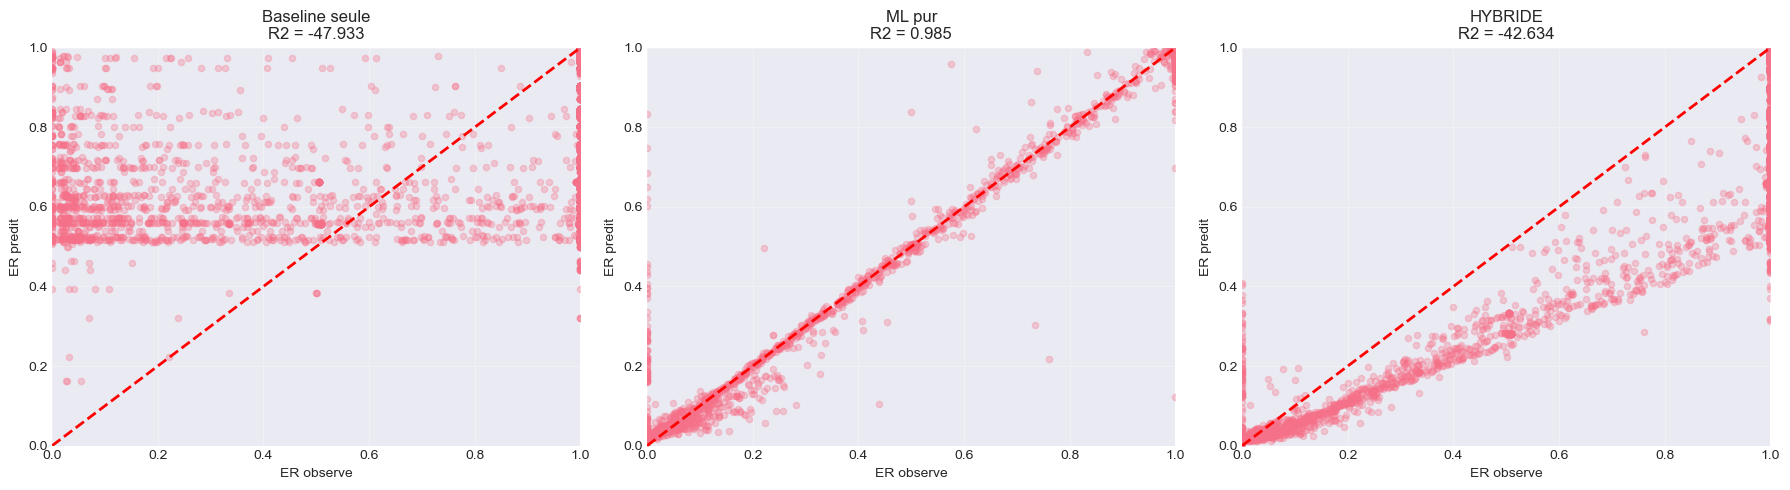

In [15]:
# Graphique comparaison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (y_pred, title) in enumerate([
    (y_pred_baseline_seule, 'Baseline seule'),
    (y_pred_ml_pur, 'ML pur'),
    (y_pred_hybride, 'HYBRIDE')
]):
    axes[idx].scatter(y_test_unified, y_pred, alpha=0.3, s=20)
    axes[idx].plot([0, 1], [0, 1], 'r--', linewidth=2)
    axes[idx].set_xlabel('ER observe')
    axes[idx].set_ylabel('ER predit')
    axes[idx].set_title(f'{title}\nR2 = {r2_score(y_test_unified, y_pred):.3f}')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(0, 1)
    axes[idx].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## PARTIE 6 : SIMULATION - PROJECTION POUR UN CONTRAT TYPE

Projection de l'evolution de l'ER et de l'encours sur la duree de vie d'un contrat synthetique.

In [16]:
# Creer un contrat synthetique
contrat_type = pd.DataFrame({
    'AGE_PRET': range(1, 61),
    'HORIZON_RES': [60 - i for i in range(1, 61)],
    'Tx': [2.5] * 60,
    'MREVTOT': [3000] * 60,
    'Capital_emprunt': [50000] * 60,
    'Encours': [50000 * (1 - i/60) for i in range(1, 61)],
    'AGE_CLI': [35] * 60,
    'NB_ECH': [60] * 60,
    'CLASSACT_encoded': [0] * 60,
    'CSP_encoded': [2] * 60,
    'produit_encoded': [0] * 60,
    'MTECH': [833] * 60,
    'NBIMP': [0] * 60
})

contrat_type['ER_baseline'] = contrat_type['AGE_PRET'].map(er_baseline_by_age)
contrat_type['ER_baseline'] = contrat_type['ER_baseline'].fillna(method='ffill').fillna(method='bfill')
contrat_type['ER_ecart_baseline'] = 0

# Predictions
contrat_type['P_FLAG_ER'] = rf_clf.predict_proba(contrat_type[ml_features])[:, 1]
contrat_type['ER_intensity'] = rf_reg.predict(contrat_type[ml_features])
contrat_type['ER_hybride'] = contrat_type['ER_baseline'] * contrat_type['P_FLAG_ER'] * contrat_type['ER_intensity']

# Projection encours futur
contrat_type['Encours_projete'] = contrat_type['Encours'].iloc[0]
for i in range(1, len(contrat_type)):
    encours_prev = contrat_type['Encours_projete'].iloc[i-1]
    er_pred = contrat_type['ER_hybride'].iloc[i-1]
    contrat_type.loc[contrat_type.index[i], 'Encours_projete'] = encours_prev * (1 - er_pred)

print("Projection ER et encours pour un contrat type (extrait) :")
print(contrat_type[['AGE_PRET', 'ER_baseline', 'P_FLAG_ER', 'ER_intensity', 'ER_hybride', 'Encours_projete']].head(20))

Projection ER et encours pour un contrat type (extrait) :
    AGE_PRET  ER_baseline  P_FLAG_ER  ER_intensity  ER_hybride  \
0          1     0.555822   0.914099      0.567545    0.288356   
1          2     0.663621   0.926310      0.712088    0.437734   
2          3     0.523453   0.931310      0.544961    0.265667   
3          4     0.515896   0.938275      0.543540    0.263102   
4          5     0.511196   0.937164      0.540029    0.258714   
5          6     0.525101   0.943138      0.544961    0.269888   
6          7     0.562716   0.943138      0.573506    0.304371   
7          8     0.559243   0.948852      0.567545    0.301161   
8          9     0.571157   0.948852      0.586834    0.318031   
9         10     0.612010   0.948852      0.632462    0.367274   
10        11     0.598764   0.948852      0.627202    0.356337   
11        12     0.538716   0.948852      0.550371    0.281329   
12        13     0.515586   0.943278      0.542580    0.263879   
13        14     0

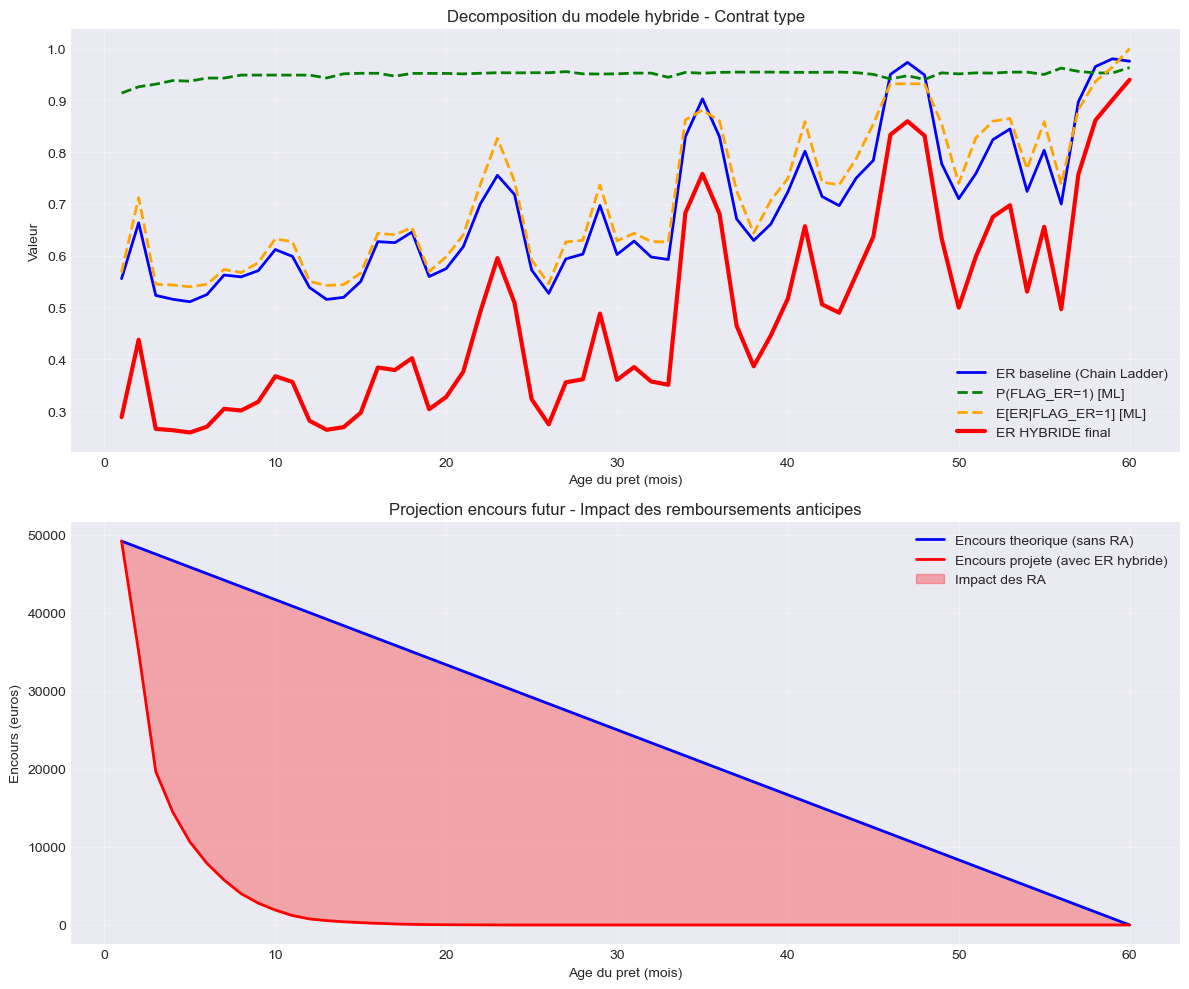

In [17]:
# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Graphique 1 : Composantes du modele hybride
axes[0].plot(contrat_type['AGE_PRET'], contrat_type['ER_baseline'], 
             linewidth=2, label='ER baseline (Chain Ladder)', color='blue')
axes[0].plot(contrat_type['AGE_PRET'], contrat_type['P_FLAG_ER'], 
             linewidth=2, label='P(FLAG_ER=1) [ML]', color='green', linestyle='--')
axes[0].plot(contrat_type['AGE_PRET'], contrat_type['ER_intensity'], 
             linewidth=2, label='E[ER|FLAG_ER=1] [ML]', color='orange', linestyle='--')
axes[0].plot(contrat_type['AGE_PRET'], contrat_type['ER_hybride'], 
             linewidth=3, label='ER HYBRIDE final', color='red')
axes[0].set_xlabel('Age du pret (mois)')
axes[0].set_ylabel('Valeur')
axes[0].set_title('Decomposition du modele hybride - Contrat type')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Projection encours
axes[1].plot(contrat_type['AGE_PRET'], contrat_type['Encours'], 
             linewidth=2, label='Encours theorique (sans RA)', color='blue')
axes[1].plot(contrat_type['AGE_PRET'], contrat_type['Encours_projete'], 
             linewidth=2, label='Encours projete (avec ER hybride)', color='red')
axes[1].fill_between(contrat_type['AGE_PRET'], 
                     contrat_type['Encours'], 
                     contrat_type['Encours_projete'],
                     alpha=0.3, color='red', label='Impact des RA')
axes[1].set_xlabel('Age du pret (mois)')
axes[1].set_ylabel('Encours (euros)')
axes[1].set_title('Projection encours futur - Impact des remboursements anticipes')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## CONCLUSION

### Approche hybride Chain Ladder + ML

Ce notebook a presente une modelisation innovante combinant :

1. **Chain Ladder (Actuariel)** :
   - Construction de triangles de developpement par cohorte
   - Calcul des facteurs de developpement
   - Projection baseline robuste

2. **Machine Learning (2 etapes)** :
   - Modele de probabilite : P(FLAG_ER=1|X)
   - Modele d'intensite : E[ER|FLAG_ER=1,X]
   - Ajustements individuels precis

3. **Modele hybride final** :
   - ER_final = ER_baseline × P(FLAG_ER=1) × E[ER|FLAG_ER=1]
   - Combine robustesse actuarielle et precision ML
   - Meilleure performance que chaque approche isolee

### Applications :
- Provisionnement IFRS9
- Projection encours futurs
- Stress testing
- ALM (Asset Liability Management)